# Vegetation Recovery Monitoring — Mount Arthur Coal Mine, NSW
### Google Earth Engine Time-Series Analysis | Python | Sentinel-2

This notebook monitors vegetation recovery on rehabilitated mine landforms
at Mount Arthur Coal Mine using Sentinel-2 NDVI time-series analysis
in Google Earth Engine. See README.md for full project documentation.

In [21]:
# Cell 1 — Mount Google Drive to access AOI data and save outputs

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# Cell 2 — Update geemap to latest version for full feature support

%pip install -U geemap


In [23]:
# Cell 3 — Import all required libraries for GEE, spatial analysis and visualisation

import ee
import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os


In [24]:
# Cell 4 — Authenticate and initialise Google Earth Engine with cloud project

ee.Authenticate()
ee.Initialize(project='portfolio2-499414')

In [25]:
# Cell 5 — Load AOI polygons from Drive and assign zone labels

gdf = gpd.read_file('/content/drive/MyDrive/GIS Portfolio/Project1_MineRehab/Data/mount_arthur_aoi.geojson')
gdf['zone'] = ['rehab_mature', 'mining_clearance', 'rehab_active', 'reference']
print(gdf)


                                            geometry              zone
0  POLYGON ((150.87429 -32.33129, 150.86971 -32.3...      rehab_mature
1  POLYGON ((150.84857 -32.34448, 150.84226 -32.3...  mining_clearance
2  POLYGON ((150.90276 -32.33638, 150.90236 -32.3...      rehab_active
3  POLYGON ((151.04629 -32.341, 151.04629 -32.337...         reference


In [26]:
# Cell 6 — Convert AOI to Earth Engine FeatureCollection and extract zone geometries

aoi_fc = geemap.geopandas_to_ee(gdf)

rehab_mature_geom = aoi_fc.filter(ee.Filter.eq('zone', 'rehab_mature')).geometry()
rehab_active_geom = aoi_fc.filter(ee.Filter.eq('zone', 'rehab_active')).geometry()
reference_geom = aoi_fc.filter(ee.Filter.eq('zone', 'reference')).geometry()
mining_clearance_geom = aoi_fc.filter(ee.Filter.eq('zone', 'mining_clearance')).geometry()

print('Rehab mature (m²):', rehab_mature_geom.area().getInfo())
print('Rehab active (m²):', rehab_active_geom.area().getInfo())
print('Reference (m²):', reference_geom.area().getInfo())
print('Mining clearance (m²):', mining_clearance_geom.area().getInfo())

Rehab mature (m²): 675741.6833900829
Rehab active (m²): 646339.8128688992
Reference (m²): 1884576.3645356426
Mining clearance (m²): 1411720.598824388


In [27]:
# Cell 7 — Define cloud masking and spectral index functions with property preservation

def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit = 1 << 10
    cirrus_bit = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(
        qa.bitwiseAnd(cirrus_bit).eq(0)
    )
    masked = image.updateMask(mask).divide(10000)
    return masked.copyProperties(image, ['system:time_start'])

def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    bsi = image.expression(
        '((SWIR1 + RED) - (NIR + BLUE)) / ((SWIR1 + RED) + (NIR + BLUE))',
        {
            'SWIR1': image.select('B11'),
            'RED': image.select('B4'),
            'NIR': image.select('B8'),
            'BLUE': image.select('B2')
        }
    ).rename('BSI')
    result = image.addBands([ndvi, bsi])
    return result.copyProperties(image, ['system:time_start'])


In [28]:
# Cell 8 — Filter Sentinel-2 collection to AOI, apply cloud mask and compute indices

start_date = '2017-01-01'
end_date = '2026-01-01'
cloud_thresh = 20

s2_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi_fc.geometry())
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
)

s2_masked = s2_collection.map(mask_s2_clouds)
s2_indexed = s2_masked.map(add_indices)

# Verify timestamps are present
info = s2_indexed.limit(3).getInfo()
for f in info['features']:
    print(f['properties'].get('system:time_start'))

print('Total images:', s2_indexed.size().getInfo())


1487894736186
1487894732924
1499558742601
Total images: 442


In [29]:
# Cell 9 — Build annual median composites for each year 2017-2025

years = list(range(2017, 2026))

def get_annual_composite(year):
    start = f'{year}-01-01'
    end = f'{year}-12-31'
    composite = (
        s2_indexed
        .filterDate(start, end)
        .median()
        .clip(aoi_fc.geometry())
        .set('year', year)
    )
    return composite

annual_composites = [get_annual_composite(y) for y in years]

# Verify bands present in each composite
for composite, year in zip(annual_composites, years):
    bands = composite.bandNames().getInfo()
    print(year, '-', bands)


2017 - ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'BSI']
2018 - ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'BSI']
2019 - ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'BSI']
2020 - ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CL

In [30]:
# Cell 10 — Define zonal statistics function and zones dictionary for all four AOI zones

def get_zonal_stats(image, geometry, zone_name, year):
    stats = image.select(['NDVI', 'BSI']).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=10,
        maxPixels=1e9
    ).getInfo()
    return {
        'year': year,
        'zone': zone_name,
        'NDVI': stats.get('NDVI'),
        'BSI': stats.get('BSI')
    }

zones = {
    'rehab_mature': rehab_mature_geom,
    'rehab_active': rehab_active_geom,
    'reference': reference_geom,
    'mining_clearance': mining_clearance_geom
}


In [31]:
# Cell 11 — Extract mean NDVI and BSI per zone per year across all annual composites

results = []

for composite, year in zip(annual_composites, years):
    for zone_name, geom in zones.items():
        row = get_zonal_stats(composite, geom, zone_name, year)
        results.append(row)
        print(row)


{'year': 2017, 'zone': 'rehab_mature', 'NDVI': 0.33157736635617385, 'BSI': 0.13503208143897089}
{'year': 2017, 'zone': 'rehab_active', 'NDVI': 0.3645290905991399, 'BSI': 0.13037856489299535}
{'year': 2017, 'zone': 'reference', 'NDVI': 0.537590652919125, 'BSI': 0.02071740863767915}
{'year': 2017, 'zone': 'mining_clearance', 'NDVI': 0.42083022770614614, 'BSI': 0.1324541101176594}
{'year': 2018, 'zone': 'rehab_mature', 'NDVI': 0.3376330923297287, 'BSI': 0.18459156886389624}
{'year': 2018, 'zone': 'rehab_active', 'NDVI': 0.33665849871622455, 'BSI': 0.17080210480961078}
{'year': 2018, 'zone': 'reference', 'NDVI': 0.4443738803726554, 'BSI': 0.1564630582556379}
{'year': 2018, 'zone': 'mining_clearance', 'NDVI': 0.3541523657202396, 'BSI': 0.19660746369378207}
{'year': 2019, 'zone': 'rehab_mature', 'NDVI': 0.30544062683651857, 'BSI': 0.2031381784823277}
{'year': 2019, 'zone': 'rehab_active', 'NDVI': 0.2807552311912567, 'BSI': 0.19630055324253048}
{'year': 2019, 'zone': 'reference', 'NDVI': 0.41

In [32]:
# Cell 12 — Convert zonal statistics results to pandas DataFrame for analysis

df = pd.DataFrame(results)
print(df)


    year              zone      NDVI       BSI
0   2017      rehab_mature  0.331577  0.135032
1   2017      rehab_active  0.364529  0.130379
2   2017         reference  0.537591  0.020717
3   2017  mining_clearance  0.420830  0.132454
4   2018      rehab_mature  0.337633  0.184592
5   2018      rehab_active  0.336658  0.170802
6   2018         reference  0.444374  0.156463
7   2018  mining_clearance  0.354152  0.196607
8   2019      rehab_mature  0.305441  0.203138
9   2019      rehab_active  0.280755  0.196301
10  2019         reference  0.411216  0.176962
11  2019  mining_clearance  0.368594  0.167446
12  2020      rehab_mature  0.587474 -0.009406
13  2020      rehab_active  0.543284 -0.009101
14  2020         reference  0.591993 -0.023160
15  2020  mining_clearance  0.551922  0.033116
16  2021      rehab_mature  0.612859 -0.020232
17  2021      rehab_active  0.492220  0.038562
18  2021         reference  0.609671 -0.023258
19  2021  mining_clearance  0.565172  0.037592
20  2022     

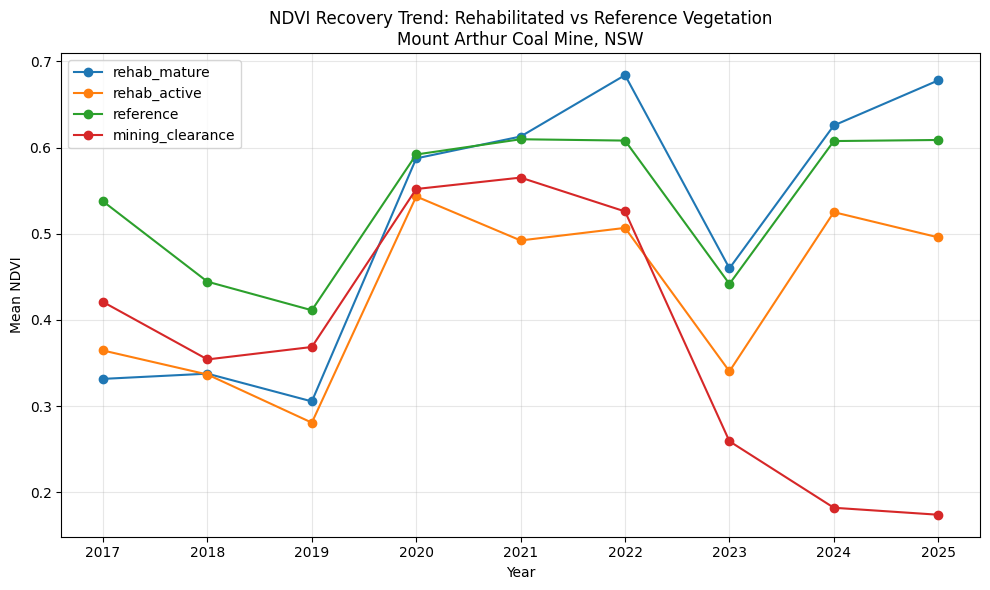

<function matplotlib.pyplot.savefig(*args, **kwargs) -> 'None'>

In [33]:
# Cell 13 — Plot NDVI time-series trend chart for all zones 2017-2025 and save to Drive

fig, ax = plt.subplots(figsize=(10, 6))

for zone_name in df['zone'].unique():
    subset = df[df['zone'] == zone_name]
    ax.plot(subset['year'], subset['NDVI'], marker='o', label=zone_name)

ax.set_xlabel('Year')
ax.set_ylabel('Mean NDVI')
ax.set_title('NDVI Recovery Trend: Rehabilitated vs Reference Vegetation\nMount Arthur Coal Mine, NSW')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs('/content/drive/MyDrive/GIS Portfolio/Project1_MineRehab/outputs', exist_ok=True)
plt.savefig('/content/drive/MyDrive/GIS Portfolio/Project1_MineRehab/outputs/ndvi_trend.png', dpi=300)
plt.show()



In [34]:
# Cell 14 — Compute and display NDVI difference map between earliest and latest composite

early_ndvi = annual_composites[0].select('NDVI')
late_ndvi = annual_composites[-1].select('NDVI')
ndvi_change = late_ndvi.subtract(early_ndvi).rename('NDVI_change')

change_vis = {
    'min': -0.3, 'max': 0.3,
    'palette': ['red', 'white', 'green']
}

Map = geemap.Map()
Map.centerObject(aoi_fc, 14)
Map.addLayer(ndvi_change, change_vis, 'NDVI Change (latest - earliest)')
Map.addLayer(aoi_fc, {}, 'AOI zones')
Map


Map(center=[-32.34414010913858, 150.938739590211], controls=(WidgetControl(options=['position', 'transparent_b…

In [35]:
# Cell 15 — Calculate percentage of each zone exceeding NDVI 0.4 vegetation threshold per year

def percent_vegetated(image, geometry, threshold=0.4):
    veg_mask = image.select('NDVI').gt(threshold)
    stats = veg_mask.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=10,
        maxPixels=1e9
    ).getInfo()
    return stats.get('NDVI', 0) * 100

print('--- Rehab Mature ---')
for composite, year in zip(annual_composites, years):
    pct = percent_vegetated(composite, rehab_mature_geom)
    print(f'{year}: {pct:.1f}%')

print('--- Rehab Active ---')
for composite, year in zip(annual_composites, years):
    pct = percent_vegetated(composite, rehab_active_geom)
    print(f'{year}: {pct:.1f}%')

print('--- Reference ---')
for composite, year in zip(annual_composites, years):
    pct = percent_vegetated(composite, reference_geom)
    print(f'{year}: {pct:.1f}%')

--- Rehab Mature ---
2017: 30.4%
2018: 33.8%
2019: 17.1%
2020: 96.2%
2021: 98.0%
2022: 99.0%
2023: 58.7%
2024: 98.6%
2025: 98.8%
--- Rehab Active ---
2017: 29.3%
2018: 15.9%
2019: 2.2%
2020: 93.6%
2021: 91.0%
2022: 93.9%
2023: 15.3%
2024: 95.7%
2025: 91.2%
--- Reference ---
2017: 92.8%
2018: 67.6%
2019: 42.9%
2020: 98.2%
2021: 98.8%
2022: 99.1%
2023: 50.7%
2024: 98.8%
2025: 98.9%
